In [2]:
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

In [3]:
np.random.seed(0) #For reproducibility

In [4]:
#Dogs: higher ear flappiness index, lower whisker length
dogs_whisker_lenth=np.random.normal(loc=5,scale=1, size=10)
dogs_ear_flappiness_index=np.random.normal(loc=8, scale=1, size=10)

In [5]:
#Cats:lower ear flappiness index, higher whisker length
cats_whisheker_length=np.random.normal(loc=8, scale=1, size=10)
cats_ear_flappiness_index=np.random.normal(loc=5,scale=1, size=10)

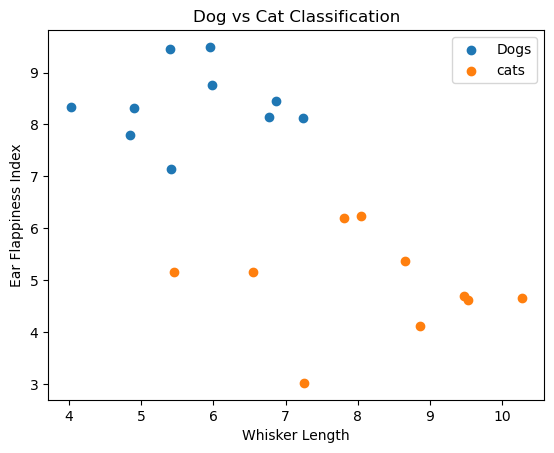

In [6]:
#Plot the data
plt.scatter(dogs_whisker_lenth, dogs_ear_flappiness_index, label="Dogs")
plt.scatter(cats_whisheker_length,cats_ear_flappiness_index, label="cats")
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Dog vs Cat Classification')
plt.legend()
plt.show()

In [7]:
#Implementing the random linear classifier ALgorithm

def random_linear_classifier(data_dogs, data_cats,k,d):
    #d is the number of features
    best_error=float('inf')
    best_theta=None
    best_theta0=None

    for _ in range(k):
        theta=np.random.normal(size=d)
        theta0=np.random.normal()

        error=compute_error(data_dogs,data_cats,theta,theta0)

        if error<best_error:
            best_error=error
            best_theta=theta
            best_theta0=theta0

    return best_theta, best_theta0


In [8]:
def compute_error(data_dogs, data_cats, theta, theta0):
    error=0
    for x_dog in data_dogs:
        if np.dot(theta, x_dog)+theta0<=0:
            error+=1
    for x_cat in data_cats:
        if np.dot(theta, x_cat)+theta0>0:
            error+=1
    return error

In [11]:
#Prepare data for algorithm
dogs_data=np.vstack((dogs_whisker_lenth, dogs_ear_flappiness_index)).T
cats_data=np.vstack((cats_whisheker_length, cats_ear_flappiness_index)).T


In [12]:
dogs_data

array([[6.76405235, 8.14404357],
       [5.40015721, 9.45427351],
       [5.97873798, 8.76103773],
       [7.2408932 , 8.12167502],
       [6.86755799, 8.44386323],
       [4.02272212, 8.33367433],
       [5.95008842, 9.49407907],
       [4.84864279, 7.79484174],
       [4.89678115, 8.3130677 ],
       [5.4105985 , 7.14590426]])

In [13]:
#Run random linear classifier algorithm
k=100 #number of iterations
d=2 #Number of features
best_theta, best_theta0=random_linear_classifier(dogs_data, cats_data,k,d)

In [14]:
best_theta

array([-1.07075262,  1.05445173])

In [15]:
best_theta0

-0.40317694697317963

In [16]:
#Plot the boundary 
x_vals=np.linspace(2,10,100)
y_vals=(-best_theta[0]/best_theta[1])*x_vals-(best_theta0/best_theta[1])


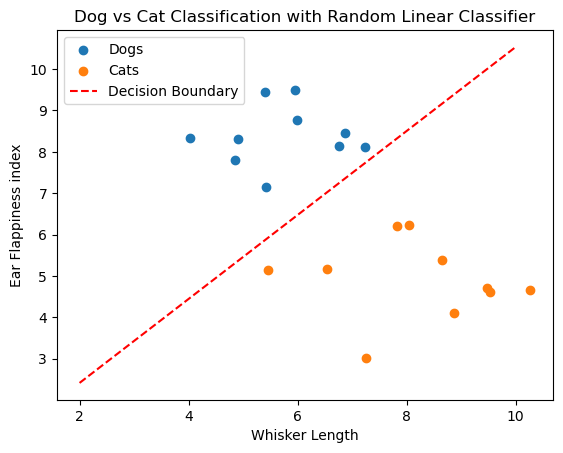

In [19]:
plt.scatter(dogs_whisker_lenth,dogs_ear_flappiness_index,label="Dogs")
plt.scatter(cats_whisheker_length,cats_ear_flappiness_index,label="Cats")
plt.plot(x_vals,y_vals,color='red',linestyle='--',label="Decision Boundary")
plt.xlabel("Whisker Length")
plt.ylabel("Ear Flappiness index")
plt.title("Dog vs Cat Classification with Random Linear Classifier")
plt.savefig("Dogs vs Cat")
plt.legend()
plt.show()
